# Dropout Analysis Notebook

This notebook analyzes dropout experiments with message loss patterns from Weights & Biases. The analysis focuses on how different dropout rates affect model performance under various message loss conditions, similar to the distributed transformer inference scenarios.

## Import Required Libraries

Import necessary libraries for data processing, visualization, and accessing Weights & Biases experiment data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm
import wandb

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Setup Weights & Biases API Connection

Initialize the Weights & Biases API connection and define project parameters for accessing dropout experiment data with message loss patterns.

In [2]:
# Initialize Weights & Biases API
api = wandb.Api()

# Project configuration for dropout analysis
ENTITY = "distributed_transformer"
PROJECT = "dropoutV2"  # Project containing dropout experiments with message loss
PRUNING_STEP = 0  # Fixed pruning step to focus on dropout analysis

print("W&B API initialized successfully")
print(f"Target project: {ENTITY}/{PROJECT}")
print(f"Fixed pruning step: {PRUNING_STEP}")

W&B API initialized successfully
Target project: distributed_transformer/dropoutV2
Fixed pruning step: 0


## Define Data Loading Functions

Create functions to load dropout experiment data from W&B runs, focusing on the relationship between partial layer dropout probability and message loss patterns.

In [3]:
def load_dropout_message_loss_data():
    """
    Load dropout experiment data with message loss patterns from Weights & Biases.
    
    Returns:
        dict: Dictionary containing data organized by dataset and dropout probability
    """
    runs = api.runs(ENTITY + "/" + PROJECT)
    
    data_all = {}
    
    for run in tqdm(runs, desc="Loading dropout message loss data"):
        # Get test loss and message loss data
        data_single = run.history(samples=10000, keys=["test_loss_message_loss", "message_loss"])
        
        # Skip runs without required data
        if "test_loss_message_loss" not in data_single.columns:
            continue
            
        # Filter by pruning step to focus on dropout analysis
        if run.config["pruning_step"] != PRUNING_STEP:
            continue
            
        # Extract experiment parameters
        dataset = run.config["dataset"]["name"]
        partial_layer_dropout_prob = run.config["model"]["partial_layer_dropout_prob"]
        message_loss = data_single["message_loss"]
        test_loss = data_single["test_loss_message_loss"]
        
        # Organize data by dataset and dropout probability
        if dataset not in data_all:
            data_all[dataset] = {}
        
        if partial_layer_dropout_prob not in data_all[dataset]:
            data_all[dataset][partial_layer_dropout_prob] = {
                "message_loss": message_loss, 
                "test_loss": []
            }
        
        # Append test loss data for this run
        data_all[dataset][partial_layer_dropout_prob]["test_loss"].append(test_loss)
    
    return data_all

def calculate_dropout_statistics(data_dict):
    """
    Calculate statistics for dropout experiments across different message loss levels.
    
    Args:
        data_dict (dict): Raw experiment data
    
    Returns:
        dict: Dictionary with calculated statistics
    """
    stats = {}
    
    for dataset in data_dict:
        stats[dataset] = {}
        
        for dropout_prob in data_dict[dataset]:
            message_loss = data_dict[dataset][dropout_prob]["message_loss"]
            test_losses = data_dict[dataset][dropout_prob]["test_loss"]
            
            # Convert test losses to numpy array for easier manipulation
            loss_array = np.array(test_losses)
            
            # Calculate statistics across runs for each message loss level
            means = np.mean(loss_array, axis=0)
            mins = np.min(loss_array, axis=0)
            maxs = np.max(loss_array, axis=0)
            stds = np.std(loss_array, axis=0)
            
            stats[dataset][dropout_prob] = {
                'message_loss_levels': message_loss,
                'mean_loss': means,
                'min_loss': mins,
                'max_loss': maxs,
                'std_loss': stds,
                'num_runs': len(test_losses)
            }
    
    return stats

## Load Dropout Experiment Data

Execute data loading to collect dropout experiments with message loss patterns from multiple runs.

In [4]:
# Load dropout experiment data
print("Loading dropout experiment data with message loss patterns...")
dropout_data = load_dropout_message_loss_data()

# Display summary of loaded data
print(f"\nLoaded data for datasets: {list(dropout_data.keys())}")

for dataset in dropout_data:
    print(f"\nDataset: {dataset}")
    dropout_probs = list(dropout_data[dataset].keys())
    print(f"  Dropout probabilities analyzed: {sorted(dropout_probs)}")
    
    for dropout_prob in sorted(dropout_probs):
        num_runs = len(dropout_data[dataset][dropout_prob]["test_loss"])
        message_loss_points = len(dropout_data[dataset][dropout_prob]["message_loss"])
        print(f"    Dropout prob {dropout_prob}: {num_runs} runs, {message_loss_points} message loss points")

Loading dropout experiment data with message loss patterns...


Loading dropout message loss data: 100%|██████████| 160/160 [02:19<00:00,  1.15it/s]


Loaded data for datasets: ['ETT', 'ICD', 'traffic_hourly_dataset', 'london_smart_meters_dataset']

Dataset: ETT
  Dropout probabilities analyzed: [0, 0.01, 0.05, 0.1]
    Dropout prob 0: 10 runs, 11 message loss points
    Dropout prob 0.01: 10 runs, 11 message loss points
    Dropout prob 0.05: 10 runs, 11 message loss points
    Dropout prob 0.1: 10 runs, 11 message loss points

Dataset: ICD
  Dropout probabilities analyzed: [0, 0.01, 0.05, 0.1]
    Dropout prob 0: 10 runs, 11 message loss points
    Dropout prob 0.01: 10 runs, 11 message loss points
    Dropout prob 0.05: 10 runs, 11 message loss points
    Dropout prob 0.1: 10 runs, 11 message loss points

Dataset: traffic_hourly_dataset
  Dropout probabilities analyzed: [0, 0.01, 0.05, 0.1]
    Dropout prob 0: 10 runs, 11 message loss points
    Dropout prob 0.01: 10 runs, 11 message loss points
    Dropout prob 0.05: 10 runs, 11 message loss points
    Dropout prob 0.1: 10 runs, 11 message loss points

Dataset: london_smart_mete

## Define Analysis Functions

In [5]:
def calculate_dropout_message_loss_statistics(dataset_data):
    """
    Calculate statistics for dropout experiments across different message loss levels.
    
    Args:
        dataset_data (dict): Dictionary with dropout probabilities as keys, containing message_loss and test_loss data
    
    Returns:
        dict: Dictionary with dropout probabilities as keys and statistics as values
    """
    stats = {}
    
    for dropout_prob in dataset_data:
        message_loss_probs = dataset_data[dropout_prob]["message_loss"]
        loss = np.array(dataset_data[dropout_prob]["test_loss"])
        
        # Calculate statistics across runs
        means = np.mean(loss, axis=0)
        mins = np.min(loss, axis=0)
        maxs = np.max(loss, axis=0)
        stds = np.std(loss, axis=0)
        
        stats[dropout_prob] = {
            'message_loss_probs': message_loss_probs,
            'mean_loss': means,
            'min_loss': mins,
            'max_loss': maxs,
            'std_loss': stds,
            'num_runs': len(dataset_data[dropout_prob]["test_loss"])
        }
    
    return stats

def plot_dropout_statistics(dataset_name, stats_dict):
    """
    Create a comprehensive dropout analysis plot from calculated statistics.
    
    Args:
        dataset_name (str): Name of the dataset to plot
        stats_dict (dict): Dictionary containing calculated statistics for each dropout probability
        
    Returns:
        matplotlib.figure.Figure: The created figure
    """
    plt.figure(figsize=(12, 8))
    
    # Colors for different dropout rates
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    # Plot each dropout probability
    for i, dropout_prob in enumerate(sorted(stats_dict.keys())):
        color = colors[i % len(colors)]
        stats = stats_dict[dropout_prob]
        
        message_loss_probs = stats['message_loss_probs']
        means = stats['mean_loss']
        mins = stats['min_loss']
        maxs = stats['max_loss']
        
        # Create plot with shaded area
        line = plt.plot(message_loss_probs, means, label=f'Dropout rate: {dropout_prob}', 
                       color=color, marker='o', linewidth=2)
        plt.fill_between(message_loss_probs, mins, maxs, alpha=0.3, color=color)
    
    # Customize plot
    plt.xlabel('Message Loss Probability', fontsize=14)
    plt.ylabel('Test Loss', fontsize=14)
    plt.title(f'Dropout Analysis with Message Loss - Dataset: {dataset_name}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return plt.gcf()

def save_dropout_statistics_to_csv(dataset_name, stats_dict, base_path="/home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data"):
    """
    Save dropout analysis statistics to CSV files.
    
    Args:
        dataset_name (str): Name of the dataset
        stats_dict (dict): Dictionary containing calculated statistics for each dropout probability
        base_path (str): Base directory path for saving CSV files
    """
    import os
    
    # Create directory if it doesn't exist
    os.makedirs(base_path, exist_ok=True)
    
    for dropout_prob in stats_dict:
        stats = stats_dict[dropout_prob]
        
        df = pd.DataFrame({
            "message_loss_prob": [p * 100 for p in stats['message_loss_probs']],
            "mean_loss": stats['mean_loss'],
            "min_loss": stats['min_loss'],
            "max_loss": stats['max_loss'],
            "std_loss": stats['std_loss']
        })
        
        filepath = os.path.join(base_path, f"{dataset_name}_dropout_{int(round(dropout_prob*100))}.csv")
        df.to_csv(filepath, index=False)
        print(f"Data saved to: {filepath}")

def create_dropout_analysis_plot(dataset_name, dataset_data, save_csv=False):
    """
    Create a comprehensive dropout analysis plot for a specific dataset.
    
    Args:
        dataset_name (str): Name of the dataset to plot
        dataset_data (dict): Dropout data for the dataset
        save_csv (bool): Whether to save data to CSV files
        
    Returns:
        dict: Calculated statistics for the dataset
    """
    # Calculate statistics
    stats = calculate_dropout_message_loss_statistics(dataset_data)

    # Calculate relative loss ratios for each dropout probability
    for dropout_prob in stats:
        if dropout_prob == 0:
            continue
        
        # Find the baseline (dropout_prob=0, message_loss_prob=0)
        if 0 in stats:
            baseline_loss = stats[0]['mean_loss'][0]  # First data point (message_loss_prob=0)
            baesline_loss_end = stats[0]['mean_loss'][-1]  # Last data point (message_loss_prob=10%)
            print(f"Baseline loss increase: {baesline_loss_end / baseline_loss:.3f}")
            
            # Find the message loss probability that matches the dropout probability
            message_loss_probs = stats[dropout_prob]['message_loss_probs']
            mean_losses = stats[dropout_prob]['mean_loss']
            
            # Find closest message loss probability to dropout probability
            closest_idx = np.argmin(np.abs(np.array(message_loss_probs) - dropout_prob))
            matching_loss = mean_losses[closest_idx]
            
            # Calculate ratio
            loss_ratio = matching_loss / baseline_loss
            stats[dropout_prob]['loss_ratio_vs_baseline'] = loss_ratio
            
            print(f"Dropout prob {dropout_prob}: Loss ratio vs baseline = {loss_ratio:.3f}")

    
    # Create plot
    plot_dropout_statistics(dataset_name, stats)
    
    # Save to CSV if requested
    if save_csv:
        save_dropout_statistics_to_csv(dataset_name, stats)
    
    return stats


# Plot Data


Creating dropout analysis plot for ETT...
Baseline loss increase: 1.338
Dropout prob 0.01: Loss ratio vs baseline = 1.023
Baseline loss increase: 1.338
Dropout prob 0.05: Loss ratio vs baseline = 1.042
Baseline loss increase: 1.338
Dropout prob 0.1: Loss ratio vs baseline = 1.040


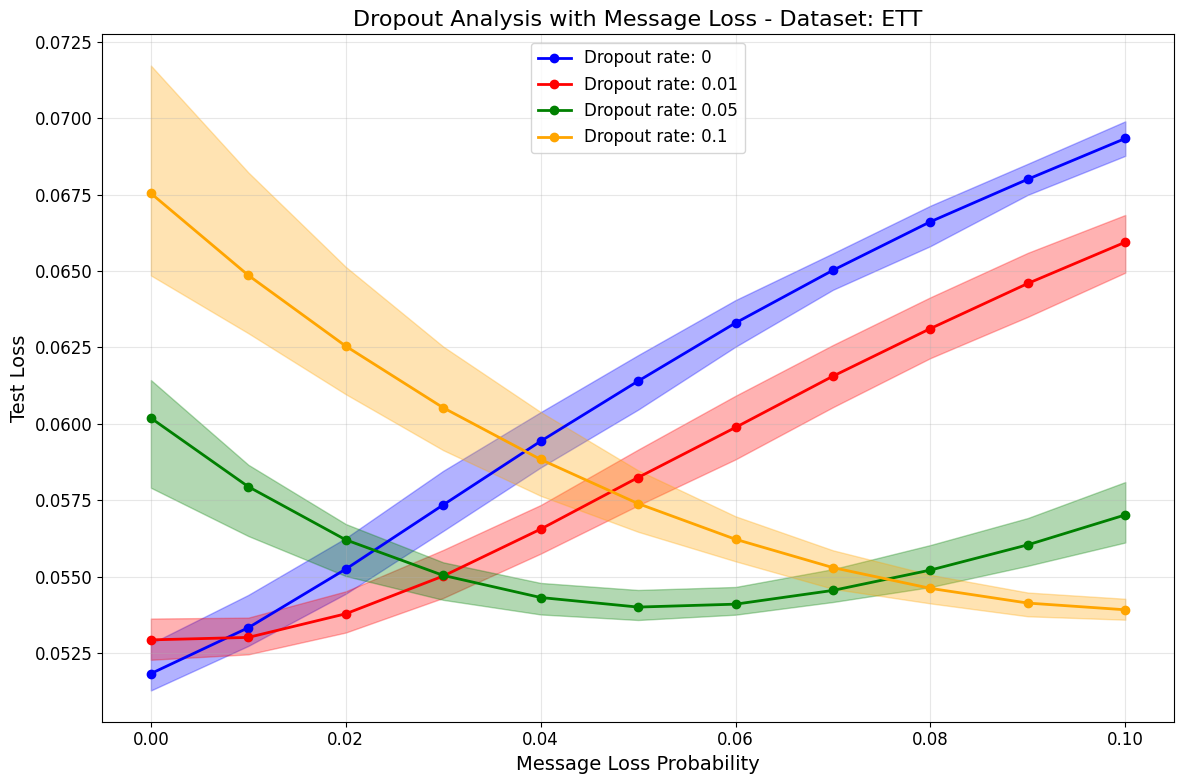

Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ETT_dropout_0.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ETT_dropout_1.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ETT_dropout_5.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ETT_dropout_10.csv
Completed analysis for ETT

Creating dropout analysis plot for ICD...
Baseline loss increase: 3.238
Dropout prob 0.01: Loss ratio vs baseline = 1.080
Baseline loss increase: 3.238
Dropout prob 0.05: Loss ratio vs baseline = 1.168
Baseline loss increase: 3.238
Dropout prob 0.1: Loss ratio vs baseline = 1.236


<Figure size 1000x600 with 0 Axes>

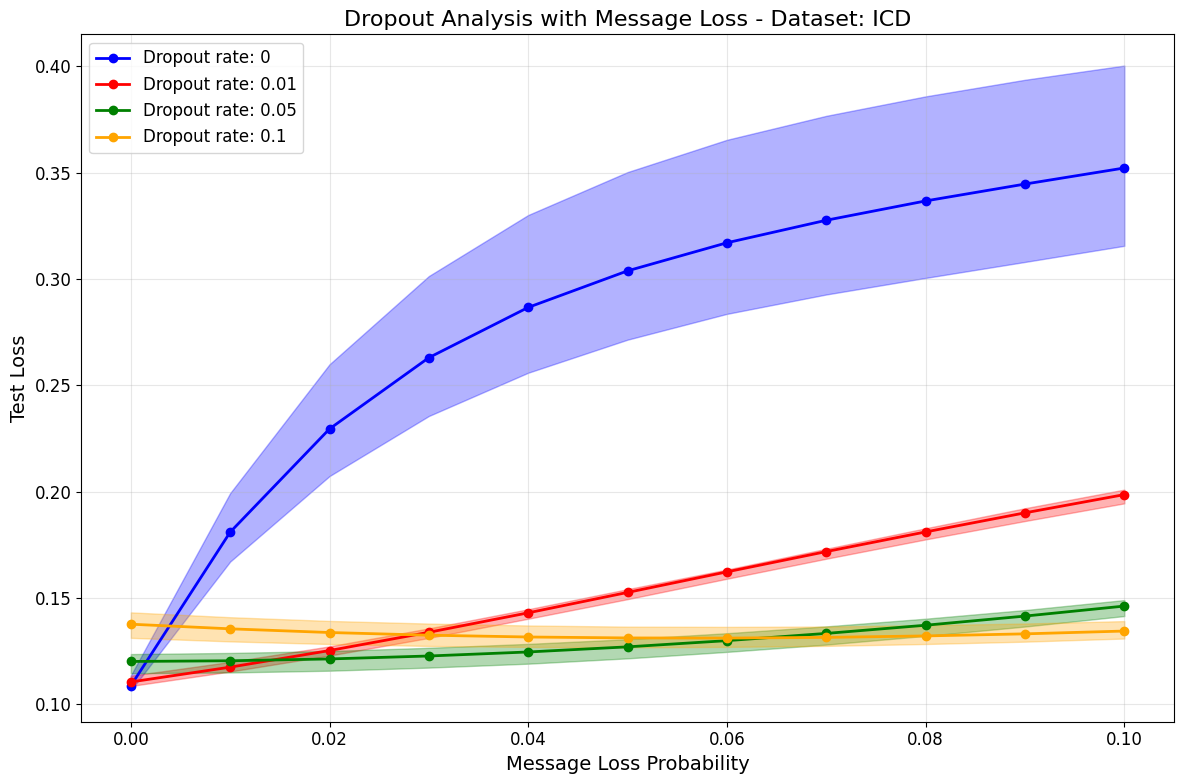

Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ICD_dropout_0.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ICD_dropout_1.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ICD_dropout_5.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ICD_dropout_10.csv
Completed analysis for ICD

Creating dropout analysis plot for traffic_hourly_dataset...
Baseline loss increase: 2.481
Dropout prob 0.01: Loss ratio vs baseline = 1.034
Baseline loss increase: 2.481
Dropout prob 0.05: Loss ratio vs baseline = 1.071
Baseline loss increase: 2.481
Dropout prob 0.1: Loss ratio vs baseline = 1.085


<Figure size 1000x600 with 0 Axes>

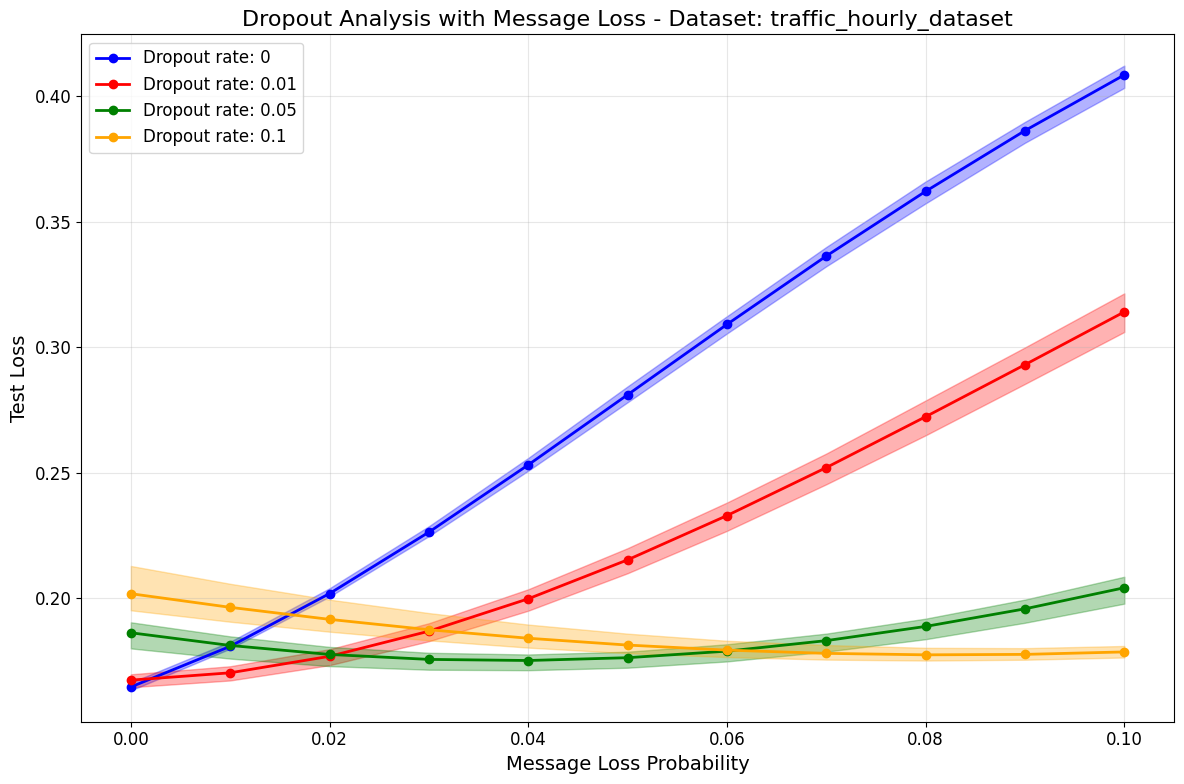

Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/traffic_hourly_dataset_dropout_0.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/traffic_hourly_dataset_dropout_1.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/traffic_hourly_dataset_dropout_5.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/traffic_hourly_dataset_dropout_10.csv
Completed analysis for traffic_hourly_dataset

Creating dropout analysis plot for london_smart_meters_dataset...
Baseline loss increase: 1.373
Dropout prob 0.01: Loss ratio vs baseline = 1.007
Baseline loss increase: 1.373
Dropout prob 0.05: Loss ratio vs baseline = 1.018
Baseline loss increase: 1.373
Dropout prob 0.1: Loss ratio vs baseline = 1.025


<Figure size 1000x600 with 0 Axes>

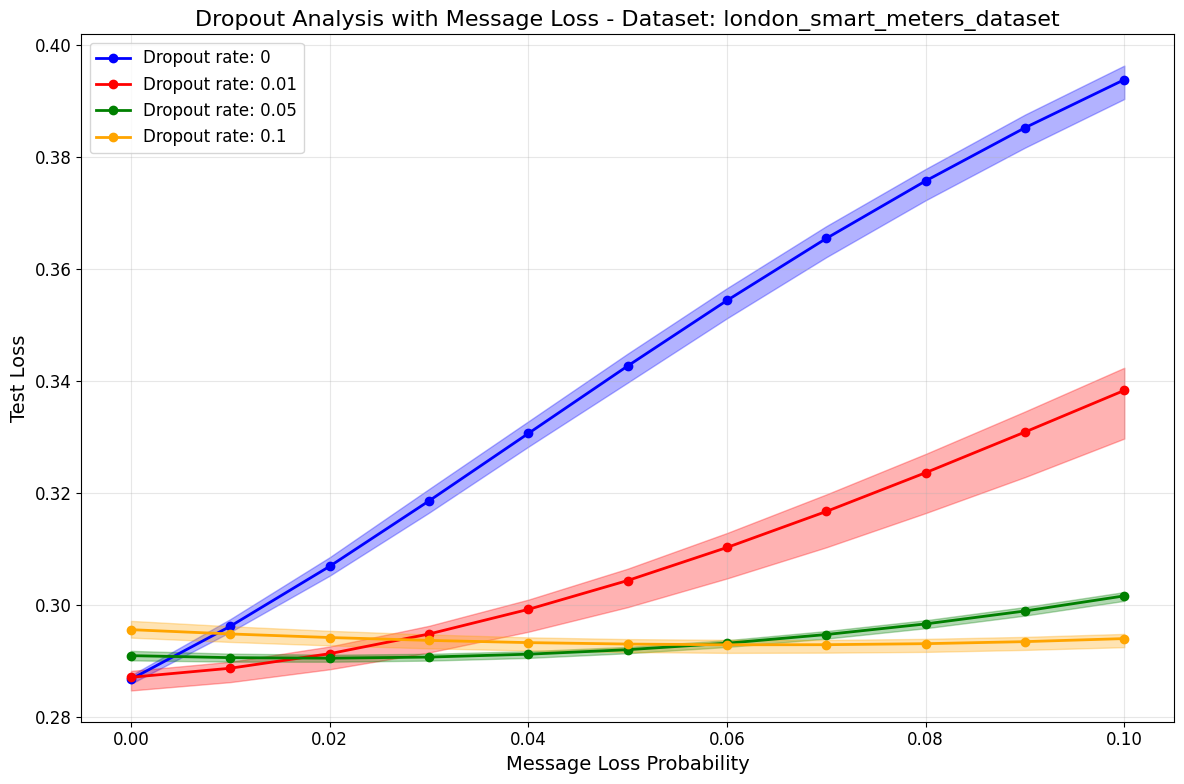

Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/london_smart_meters_dataset_dropout_0.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/london_smart_meters_dataset_dropout_1.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/london_smart_meters_dataset_dropout_5.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/london_smart_meters_dataset_dropout_10.csv
Completed analysis for london_smart_meters_dataset


<Figure size 1000x600 with 0 Axes>

In [6]:
# Plot all datasets using create_dropout_analysis_plot
for dataset_name in dropout_data.keys():
    print(f"\nCreating dropout analysis plot for {dataset_name}...")
    stats = create_dropout_analysis_plot(dataset_name, dropout_data[dataset_name], save_csv=True)
    print(f"Completed analysis for {dataset_name}")